# Transfer Learning ImageNet to CIFAR 10



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# Device configuration
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")



# ResNet18

```
model = models.resnet18(pretrained=True)
```

In [ ]:
model = models.resnet18(pretrained=True)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 196MB/s]


In [ ]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
model.fc

Linear(in_features=512, out_features=1000, bias=True)

## Change the last layer

```
model.name = nn.Linear(input_size,output_size)
```

How do we find these things?


**``summary(model, (3,224,224))``**



In [ ]:
from torchsummary import summary
model.to('cuda' if torch.cuda.is_available() else 'cpu')
summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

**``layer_names``**

```
layer_names = [name for name, _ in model.named_modules()]
for name in layer_names:
    print(name)
```
We see the name of each layer.

In [ ]:
layer_names = [name for name, _ in model.named_modules()]
for name in layer_names:
    print(name)


conv1
bn1
relu
maxpool
layer1
layer1.0
layer1.0.conv1
layer1.0.bn1
layer1.0.relu
layer1.0.conv2
layer1.0.bn2
layer1.1
layer1.1.conv1
layer1.1.bn1
layer1.1.relu
layer1.1.conv2
layer1.1.bn2
layer2
layer2.0
layer2.0.conv1
layer2.0.bn1
layer2.0.relu
layer2.0.conv2
layer2.0.bn2
layer2.0.downsample
layer2.0.downsample.0
layer2.0.downsample.1
layer2.1
layer2.1.conv1
layer2.1.bn1
layer2.1.relu
layer2.1.conv2
layer2.1.bn2
layer3
layer3.0
layer3.0.conv1
layer3.0.bn1
layer3.0.relu
layer3.0.conv2
layer3.0.bn2
layer3.0.downsample
layer3.0.downsample.0
layer3.0.downsample.1
layer3.1
layer3.1.conv1
layer3.1.bn1
layer3.1.relu
layer3.1.conv2
layer3.1.bn2
layer4
layer4.0
layer4.0.conv1
layer4.0.bn1
layer4.0.relu
layer4.0.conv2
layer4.0.bn2
layer4.0.downsample
layer4.0.downsample.0
layer4.0.downsample.1
layer4.1
layer4.1.conv1
layer4.1.bn1
layer4.1.relu
layer4.1.conv2
layer4.1.bn2
avgpool
fc


Since we know the name, we can find the input size:

In [ ]:
print(model.conv1.parameters)

<bound method Module.parameters of Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)>


In [ ]:
num_ftrs = model.fc.in_features
print(num_ftrs)

512


### Make a new last layer



In [ ]:
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10)
model = model.to(device)


In [ ]:
device

device(type='cuda', index=0)

## Prepare the data

1. Transforms
  * ``Resize``: CIFAR-10 images are 3x32x32 but Resnet needs  3x224x224.
  * ``Normalize``: Normalize to have the same stats as Imagenet.

2. Download train and test data

3. Data loaders.

In [ ]:

# transforms
transform = transforms.Compose([
    transforms.Resize(224),  # ResNet18 was trained with 224x224 images
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet means
                         std=[0.229, 0.224, 0.225])   # ImageNet stds
])

# download and load training data
train_dataset = datasets.CIFAR10(root='./data', train=True,
                                 download=True, transform=transform)

# download and load test data
test_dataset = datasets.CIFAR10(root='./data', train=False,
                                download=True, transform=transform)

# dataloaders
train_loader = DataLoader(train_dataset, batch_size=64,
                          shuffle=True, num_workers=2)

test_loader = DataLoader(test_dataset, batch_size=64,
                         shuffle=False, num_workers=2)



100%|██████████| 170M/170M [00:13<00:00, 12.9MB/s]


In [ ]:
# Number of data points there are in train_loader, and how many in test_loader

print(f"Number of data points in train_loader: {len(train_loader.dataset)}")
print(f"Number of data points in test_loader: {len(test_loader.dataset)}")

Number of data points in train_loader: 50000
Number of data points in test_loader: 10000


## Training

```
train(model, train_loader, test_loader, optimizer, epochs)
```

In [ ]:
from torch import optim
import torch
import copy
import torch.nn.functional as F
import matplotlib.pyplot as plt

def train(model, train_loader, test_loader, optimizer, epochs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # criterion
    criterion = torch.nn.CrossEntropyLoss()

    # scheduler
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)


    train_losses = []
    test_losses = []
    test_accuracies = []  # List to store accuracy for each epoch
    best_accuracy = 0  # Best accuracy found
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()  # Update the learning rate

        train_losses.append(total_loss / len(train_loader))

        model.eval()
        total_test_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                total_test_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_loss = total_test_loss / len(test_loader)
        epoch_accuracy = correct / total
        test_losses.append(epoch_loss)
        test_accuracies.append(epoch_accuracy)

        if epoch_accuracy > best_accuracy:
            best_accuracy = epoch_accuracy
            best_model_wts = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1

        print(f"Epoch {epoch+1}/{epochs}, Training Loss: {train_losses[-1]}, Testing Loss: {test_losses[-1]}, Testing Accuracy: {epoch_accuracy:.4f}")

    # Load best model weights
    model.load_state_dict(best_model_wts)
    print(f"Loaded the best model from epoch {best_epoch} with Testing Accuracy: {best_accuracy:.4f}")

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs+1), train_losses, label='Training Loss')
    plt.plot(range(1, epochs+1), test_losses, label='Testing Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs+1), test_accuracies, label='Testing Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

    return train_losses, test_losses, test_accuracies, best_accuracy

In [ ]:
def evaluate(model, data_loader, device):
    model.eval()  # Set model to evaluate mode
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total

## Train the last layer

In [ ]:
# freeze all layers
for param in model.parameters():
    param.requires_grad = False

# unfreeze the last layer
for param in model.fc.parameters():
    param.requires_grad = True


Epoch 1/5, Training Loss: 0.825295642399422, Testing Loss: 0.624443925679869, Testing Accuracy: 0.7903
Epoch 2/5, Training Loss: 0.6193876962375153, Testing Loss: 0.5948511785382677, Testing Accuracy: 0.7980
Epoch 3/5, Training Loss: 0.5903395702085836, Testing Loss: 0.6067641451480282, Testing Accuracy: 0.7908
Epoch 4/5, Training Loss: 0.5723806662327798, Testing Loss: 0.5776083854733, Testing Accuracy: 0.8014
Epoch 5/5, Training Loss: 0.567417750044552, Testing Loss: 0.6002184830273792, Testing Accuracy: 0.7967
Loaded the best model from epoch 4 with Testing Accuracy: 0.8014


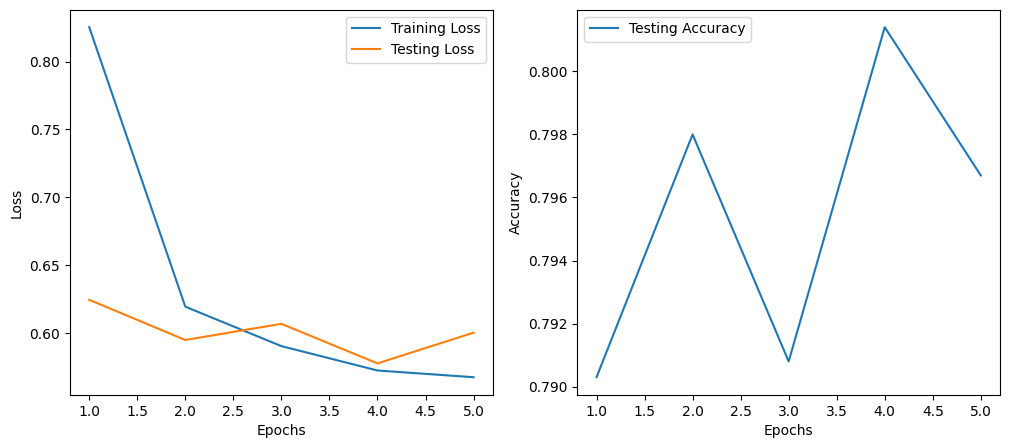

([0.825295642399422,
  0.6193876962375153,
  0.5903395702085836,
  0.5723806662327798,
  0.567417750044552],
 [0.624443925679869,
  0.5948511785382677,
  0.6067641451480282,
  0.5776083854733,
  0.6002184830273792],
 [0.7903, 0.798, 0.7908, 0.8014, 0.7967],
 0.8014)

In [ ]:
torch.manual_seed(42)
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
epochs = 5
train(model, train_loader, test_loader, optimizer, epochs)



## How did we do?

How many parameters?

In [ ]:
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [ ]:
count_trainable_parameters(model)

5130

## Unfreeze and Train



In [ ]:
# unfreeze all layers and train the whole network
for param in model.parameters():
    param.requires_grad = True

# redefine optimizer to include all parameters
optimizer = optim.Adam(model.parameters(), lr=0.0001)

Epoch 1/5, Training Loss: 0.27829185873270035, Testing Loss: 0.19342822707287824, Testing Accuracy: 0.9331
Epoch 2/5, Training Loss: 0.0882544671792699, Testing Loss: 0.2045474090512581, Testing Accuracy: 0.9343
Epoch 3/5, Training Loss: 0.0539779331864994, Testing Loss: 0.215241053491641, Testing Accuracy: 0.9357
Epoch 4/5, Training Loss: 0.04275860158679531, Testing Loss: 0.2303062924925404, Testing Accuracy: 0.9356
Epoch 5/5, Training Loss: 0.03799109759136422, Testing Loss: 0.2249077471643449, Testing Accuracy: 0.9349
Loaded the best model from epoch 3 with Testing Accuracy: 0.9357


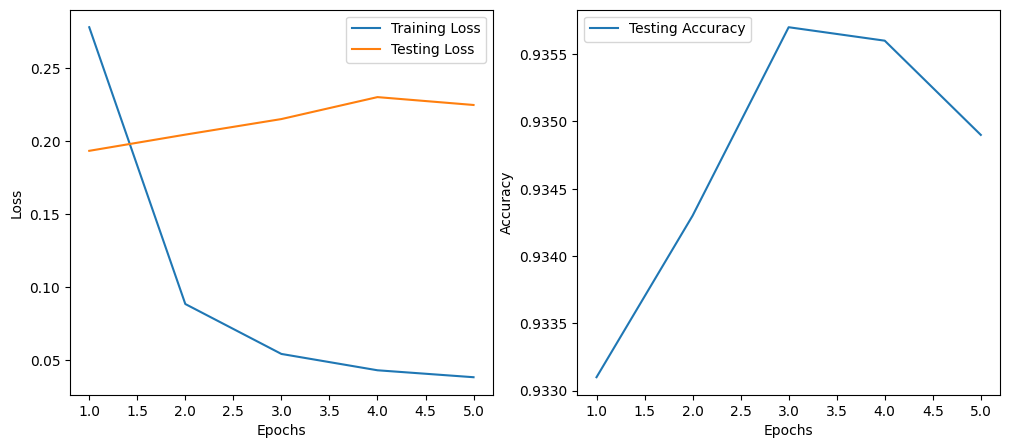

([0.27829185873270035,
  0.0882544671792699,
  0.0539779331864994,
  0.04275860158679531,
  0.03799109759136422],
 [0.19342822707287824,
  0.2045474090512581,
  0.215241053491641,
  0.2303062924925404,
  0.2249077471643449],
 [0.9331, 0.9343, 0.9357, 0.9356, 0.9349],
 0.9357)

In [ ]:
# train
optimizer = optim.Adam(model.parameters(), lr=0.0001)
epochs = 5
train(model, train_loader, test_loader, optimizer, epochs)

## How did we do?

In [ ]:
testaccuracy = evaluate(model, test_loader, device)
trainaccuracy = evaluate(model, train_loader, device)
print(f"Training Accuracy: {trainaccuracy * 100:.2f}%")
print(f"Testing Accuracy: {testaccuracy * 100:.2f}%")

### Overfitting?



### What now?

How much better can **you** do?